In [1]:
import spikeinterface.full as si
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# PATHS (set here when running standalone; overridden by main_pipeline)
try:
    mcs_file
    base_folder
except NameError:
    mcs_file    = Path(r'C:\Users\labuser\Ilaria\C5\C5_output\2026-03-27T10-48-52McsRecording_E-00218.h5')
    base_folder = Path(r'C:\Users\labuser\Ilaria\Project\Pipeline_project\mcs_tutorial_output')

In [3]:
# PARAMETERS
use_raw  = False       # False → .h5 (Multi Channel DataManager export); True → .raw binary
freq_min = 200.        # highpass cutoff (Hz)

# Sorter options for MEA data — set SORTER_MCS in main_pipeline to override.
#   'spykingcircus2'  — built into SpikeInterface, no extra install needed
#   'mountainsort5'   — pip install mountainsort5
try:
    sorter = SORTER_MCS
except NameError:
    sorter = 'spykingcircus2'

job_kwargs = dict(n_jobs=4, chunk_duration='1s', progress_bar=True)

# OPTIONAL PREPROCESSING FEATURES 
# Manual channel selection — list of channel IDs to keep; None → keep all.
# Example: manual_channel_ids = ['C1', 'C2', 'C3']
manual_channel_ids = None

# Extra bad channels — force-remove on top of auto-detected ones.
extra_bad_channel_ids = []

# Artifact removal — timestamps (seconds) to blank; leave empty to skip.
artifact_timestamps_s = []   # e.g. [10.5, 23.7, 45.2]
artifact_ms_before    = 2.0
artifact_ms_after     = 5.0

# Common reference — operator and reference type.
cref_operator  = 'median'   # 'median' (CMR) | 'average' (CAR)
cref_reference = 'global'   # 'global' | 'local' (local uses neighbouring channels only)

# WAVEFORM EXTRACTION
waveform_ms_before  = 1.5   # ms before spike peak
waveform_ms_after   = 2.0   # ms after spike peak
max_spikes_per_unit = 500   # random spike sample used for waveform extraction

# QUALITY METRICS 
metric_names = ['firing_rate', 'presence_ratio', 'snr', 'isi_violation', 'amplitude_cutoff']

# QUALITY FILTERING 
amplitude_cutoff_thresh     = 0.1
isi_violations_ratio_thresh = 1
presence_ratio_thresh       = 0.9

In [4]:
# LOAD
if use_raw:
    raw_rec = si.read_mcsraw(mcs_file)
else:
    raw_rec = si.read_mcsh5(mcs_file)
print(raw_rec)

MCSH5RecordingExtractor: 60 channels - 25000.000000 Hz - 1 segments - 1,970,000 samples 
                         78.80s (1.31 minutes) - int32 dtype - 450.90 MiB
  file_path: C:\Users\labuser\Ilaria\C5\C5_output\2026-03-27T10-48-52McsRecording_E-00218.h5


No probe geometry in file — using generic 6×10 grid (200 µm pitch).


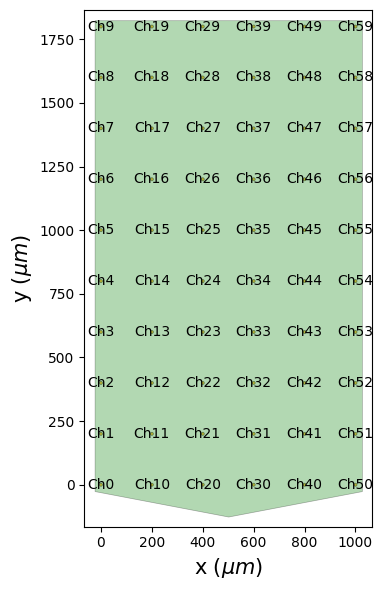

In [5]:
# PROBE SETUP
# Priority: (1) geometry embedded in file → (2) generic rectangular grid
from probeinterface import generate_multi_columns_probe

n_ch = raw_rec.get_num_channels()

if raw_rec.get_property('contact_vector') is not None:
    print(f"Probe geometry found in file — {n_ch} channels, using as-is.")
else:
    def _best_grid(n):
        best = (1, n)
        for c in range(1, int(n ** 0.5) + 1):
            if n % c == 0:
                best = (c, n // c)
        return best

    n_cols, n_rows = _best_grid(n_ch)
    probe = generate_multi_columns_probe(
        num_columns=n_cols,
        num_contact_per_column=n_rows,
        xpitch=200,   # µm, update to match your MEA electrode pitch
        ypitch=200,
    )
    probe.set_device_channel_indices(np.arange(n_ch))
    raw_rec = raw_rec.set_probe(probe, group_mode='by_probe')
    print(f"No probe geometry in file — using generic {n_cols}×{n_rows} grid (200 µm pitch).")

# PROBE MAP
fig, ax = plt.subplots(figsize=(5, 6))
si.plot_probe_map(raw_rec, ax=ax, with_channel_ids=True)
plt.tight_layout()
plt.show()

In [6]:
# PREPROCESSING

# Optional: manual channel selection
if manual_channel_ids is not None:
    raw_rec = raw_rec.channel_slice(manual_channel_ids)
    print(f"Manual selection: kept {len(manual_channel_ids)} channels")

rec1 = si.highpass_filter(raw_rec, freq_min=freq_min)

# Optional: artifact removal
if artifact_timestamps_s:
    _fs       = raw_rec.get_sampling_frequency()
    _triggers = [np.array([int(t * _fs) for t in artifact_timestamps_s], dtype=np.int64)]
    rec1 = si.remove_artifacts(rec1, list_triggers=_triggers,
                                ms_before=artifact_ms_before, ms_after=artifact_ms_after,
                                mode='zeros')
    print(f"Artifact removal: blanked {len(artifact_timestamps_s)} event(s)")

bad_channel_ids, channel_labels = si.detect_bad_channels(rec1)

# Optional: extra bad channels
if extra_bad_channel_ids:
    bad_channel_ids = list(set(bad_channel_ids.tolist()) | set(extra_bad_channel_ids))

rec2 = rec1.remove_channels(bad_channel_ids)
rec  = si.common_reference(rec2, operator='median', reference='global')
print(rec)

CommonReferenceRecording: 36 channels - 25000.000000 Hz - 1 segments - 1,970,000 samples 
                          78.80s (1.31 minutes) - int32 dtype - 270.54 MiB


C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\preprocessing\detect_bad_channels.py:300: UserWarning: Over 1/3 of channels are detected as bad. In the presence of a highnumber of dead / noisy channels, bad channel detection may fail (good channels may be erroneously labeled as dead).
  warnings.warn(


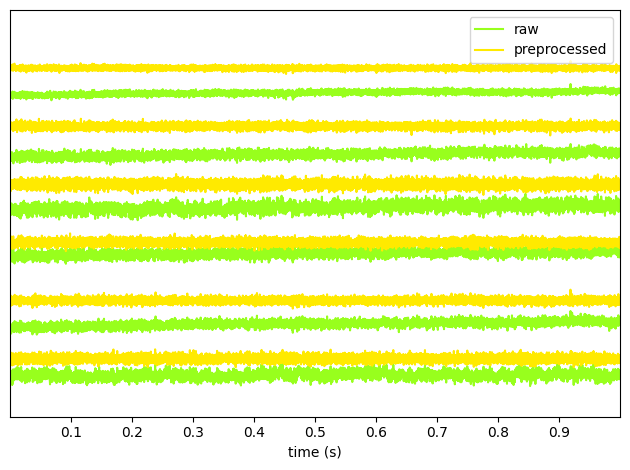

In [7]:
# TRACES VISUALIZATION
import re

_fs = raw_rec.get_sampling_frequency()
raw_2s = raw_rec.frame_slice(0, int(2 * _fs))
rec_2s = rec.frame_slice(0, int(2 * _fs))

_nat_key = lambda s: [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', s)]
_sorted_ch_ids = sorted(raw_rec.channel_ids, key=_nat_key)
_good_ch_ids = [cid for cid in _sorted_ch_ids if cid in set(rec.channel_ids)]

si.plot_traces({'raw': raw_2s, 'preprocessed': rec_2s},
               channel_ids=_good_ch_ids[:6], mode='line', backend='matplotlib')
plt.tight_layout()
plt.show()

In [8]:
# SAVE PREPROCESSED RECORDING
import gc
try:
    del analyzer
except NameError:
    pass

# release the HDF5 file handle before spawning sorter workers
del raw_rec, rec1, rec2
gc.collect()

rec = rec.save(folder=base_folder / 'preprocess', format='binary',
               overwrite=True, n_jobs=1, chunk_duration='1s', progress_bar=True)

# SPIKE SORTING
sorting = si.run_sorter(sorter, rec, folder=base_folder / f'sorting_{sorter}',
                        remove_existing_folder=True, verbose=False)
print(sorting)

write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=24,999 - chunk_memory=3.43 MiB - total_memory=3.43 MiB - chunk_duration=1.00s (999.96 ms)


write_binary_recording (no parallelization):   0%|          | 0/79 [00:00<?, ?it/s]

C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\postprocessing\template_similarity.py:345: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  overlapping_ids = overlapping_j_list[i]


NumpyFolder (NumpyFolderSorting): 13 units - 1 segments - 25.0kHz


In [9]:
# SORTING ANALYZER
# Reload from disk to get a clean file handle after the overwrite — required on Windows
#in analyzer sparse is set to false, for smaller recordings
si.set_global_job_kwargs(n_jobs=1, chunk_duration='1s', progress_bar=True)

rec_analysis = si.load(base_folder / 'preprocess')

analyzer = si.create_sorting_analyzer(sorting, rec_analysis, sparse=False, format='memory')

analyzer.compute('random_spikes', method='uniform', max_spikes_per_unit=max_spikes_per_unit)
analyzer.compute('waveforms', ms_before=waveform_ms_before, ms_after=waveform_ms_after)
analyzer.compute('templates', operators=['average', 'median', 'std'])
analyzer.compute('noise_levels')
analyzer.compute('correlograms')
analyzer.compute('unit_locations')
analyzer.compute('spike_amplitudes')
analyzer.compute('template_similarity')
print(analyzer)

compute_waveforms (no parallelization):   0%|          | 0/79 [00:00<?, ?it/s]

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

spike_amplitudes (no parallelization):   0%|          | 0/79 [00:00<?, ?it/s]

SortingAnalyzer: 36 channels - 13 units - 1 segments - memory - has recording
Loaded 8 extensions: random_spikes, waveforms, templates, noise_levels, correlograms, unit_locations, spike_amplitudes, template_similarity


In [10]:
# QUALITY METRICS
metrics_ext  = analyzer.compute('quality_metrics', metric_names=metric_names)
metrics      = metrics_ext.get_data()
print(metrics)
metrics.to_csv(base_folder / 'quality_metrics.csv')
print(f"Quality metrics saved → {base_folder / 'quality_metrics.csv'}")

    firing_rate  presence_ratio       snr  isi_violations_ratio  \
1      4.809645             1.0  2.996591              0.000000   
2     10.786802             1.0  2.985400              0.690750   
5      3.895939             1.0  3.699403              9.196915   
6     11.065990             1.0  3.219156              6.977878   
7      2.969543             1.0  4.630099              4.797039   
11    10.291878             1.0  3.883713             13.138904   
13     4.238579             1.0  4.267584             25.429381   
16     4.441624             1.0  3.197563              5.146122   
20     6.307107             1.0  2.994849              3.934539   
23     6.027919             1.0  3.106814              2.211930   
30    10.634518             1.0  2.934487              5.273950   
34     8.299492             1.0  2.764499              2.517870   
35     1.078680             1.0  7.065927              0.000000   

    isi_violations_count  amplitude_cutoff  
1               

C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\metrics\quality\misc_metrics.py:1026: UserWarning: Amplitude cutoff set to NaN for units [1, 5, 7, 13, 16, 20, 23, 35]: too few spikes (< 500).
  warnings.warn(


In [11]:
# QUALITY-BASED FILTERING
query = (
    f"(amplitude_cutoff < {amplitude_cutoff_thresh}) & "
    f"(isi_violations_ratio < {isi_violations_ratio_thresh}) & "
    f"(presence_ratio > {presence_ratio_thresh})"
)
keep_unit_ids = metrics.query(query).index.values
print(f"Keeping {len(keep_unit_ids)} / {len(sorting.unit_ids)} units after quality filtering")

Keeping 1 / 13 units after quality filtering


In [12]:
# SAVE ANALYZER
import shutil
_analyzer_folder = base_folder / 'analyzer'
if _analyzer_folder.exists():
    shutil.rmtree(_analyzer_folder)
analyzer.save_as(folder=_analyzer_folder, format='binary_folder')

C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\core\basesorting.py:384: UserWarning: The registered recording will not be persistent on disk, but only available in memory
  warnings.warn("The registered recording will not be persistent on disk, but only available in memory")


SortingAnalyzer: 36 channels - 13 units - 1 segments - binary_folder - has recording
Loaded 9 extensions: random_spikes, waveforms, templates, noise_levels, correlograms, unit_locations, spike_amplitudes, template_similarity, quality_metrics

In [13]:
# INTERACTIVE VIEWER (sigui)
# shows waveforms, ISI, amplitudes, probe map — click any unit to inspect
import spikeinterface_gui
spikeinterface_gui.run_mainwindow(analyzer)